In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

print("All good!")

All good!


In [2]:
data = {
    'area': ['Patia', 'Saheed Nagar', 'Rasulgarh', 'Old Town', 'Chandrasekharpur', 'Nayapalli'],
    'temperature': [38, 41, 40, 43, 37, 39],
    'humidity': [65, 70, 68, 75, 60, 63],
    'ndvi': [0.4, 0.2, 0.15, 0.1, 0.5, 0.35],
    'population_density': [3000, 8000, 6000, 12000, 2500, 5000]
}

df = pd.DataFrame(data)
print(df)

               area  temperature  humidity  ndvi  population_density
0             Patia           38        65  0.40                3000
1      Saheed Nagar           41        70  0.20                8000
2         Rasulgarh           40        68  0.15                6000
3          Old Town           43        75  0.10               12000
4  Chandrasekharpur           37        60  0.50                2500
5         Nayapalli           39        63  0.35                5000


In [3]:
df['risk_score'] = (
    (df['temperature'] / df['temperature'].max()) * 0.4 +
    (df['humidity'] / df['humidity'].max()) * 0.2 +
    (1 - df['ndvi'] / df['ndvi'].max()) * 0.2 +
    (df['population_density'] / df['population_density'].max()) * 0.2
)

print(df[['area', 'risk_score']].sort_values('risk_score', ascending=False))

               area  risk_score
3          Old Town    0.960000
1      Saheed Nagar    0.821395
2         Rasulgarh    0.793426
5         Nayapalli    0.674124
0             Patia    0.616822
4  Chandrasekharpur    0.545853


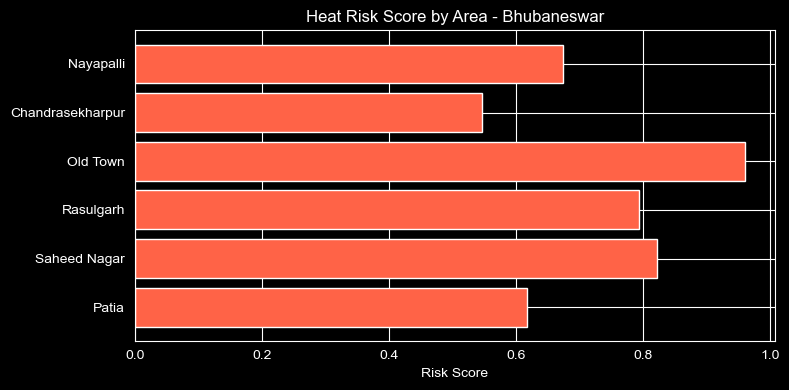

In [4]:
plt.figure(figsize=(8, 4))
plt.barh(df['area'], df['risk_score'], color='tomato')
plt.xlabel('Risk Score')
plt.title('Heat Risk Score by Area - Bhubaneswar')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.cluster import KMeans

features = df[['temperature', 'humidity', 'ndvi', 'population_density']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(features)

print(df[['area', 'risk_score', 'cluster']])

               area  risk_score  cluster
0             Patia    0.616822        2
1      Saheed Nagar    0.821395        0
2         Rasulgarh    0.793426        0
3          Old Town    0.960000        1
4  Chandrasekharpur    0.545853        2
5         Nayapalli    0.674124        0


C:\Users\ACER\anaconda3\envs\heatlas\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
cluster_map = {1: 'High Risk', 0: 'Medium Risk', 2: 'Low Risk'}
df['risk_level'] = df['cluster'].map(cluster_map)

print(df[['area', 'risk_score', 'risk_level']])

               area  risk_score   risk_level
0             Patia    0.616822     Low Risk
1      Saheed Nagar    0.821395  Medium Risk
2         Rasulgarh    0.793426  Medium Risk
3          Old Town    0.960000    High Risk
4  Chandrasekharpur    0.545853     Low Risk
5         Nayapalli    0.674124  Medium Risk


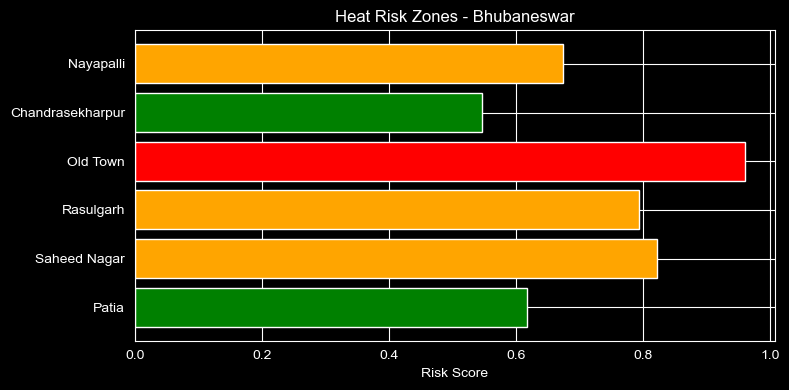

In [7]:
colors = {'High Risk': 'red', 'Medium Risk': 'orange', 'Low Risk': 'green'}

plt.figure(figsize=(8, 4))
plt.barh(df['area'], df['risk_score'], color=df['risk_level'].map(colors))
plt.xlabel('Risk Score')
plt.title('Heat Risk Zones - Bhubaneswar')
plt.tight_layout()
plt.show()

In [8]:
import folium
print(folium.__version__)

0.20.0


In [9]:
# Neighborhood coordinates + data
neighborhoods = [
    {"name": "Patia",             "lat": 20.3534, "lon": 85.8161, "risk_score": 0.616822, "cluster": "Low Risk"},
    {"name": "Saheed Nagar",      "lat": 20.2961, "lon": 85.8245, "risk_score": 0.821395, "cluster": "Medium Risk"},
    {"name": "Rasulgarh",         "lat": 20.2847, "lon": 85.8351, "risk_score": 0.793426, "cluster": "Medium Risk"},
    {"name": "Old Town",          "lat": 20.2706, "lon": 85.8322, "risk_score": 0.960000, "cluster": "High Risk"},
    {"name": "Chandrasekharpur",  "lat": 20.3000, "lon": 85.8000, "risk_score": 0.545853, "cluster": "Low Risk"},
]

# Color mapping
def get_color(cluster):
    if cluster == "High Risk":
        return "red"
    elif cluster == "Medium Risk":
        return "orange"
    else:
        return "green"

# Map banao — Bhubaneswar center
m = folium.Map(location=[20.3, 85.82], zoom_start=12)

# Har neighborhood ka marker add karo
for n in neighborhoods:
    folium.CircleMarker(
        location=[n["lat"], n["lon"]],
        radius=15,
        color=get_color(n["cluster"]),
        fill=True,
        fill_opacity=0.7,
        popup=f"{n['name']}\nRisk Score: {n['risk_score']:.2f}\n{n['cluster']}"
    ).add_to(m)

m

In [13]:
import urllib.request
import json

url = "https://api.open-meteo.com/v1/forecast?latitude=20.2961&longitude=85.8245&current=temperature_2m,relative_humidity_2m&timezone=Asia%2FKolkata"

response = urllib.request.urlopen(url)
data = json.loads(response.read())
print(data)

{'latitude': 20.281195, 'longitude': 85.843376, 'generationtime_ms': 0.05161762237548828, 'utc_offset_seconds': 19800, 'timezone': 'Asia/Kolkata', 'timezone_abbreviation': 'GMT+5:30', 'elevation': 44.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C', 'relative_humidity_2m': '%'}, 'current': {'time': '2026-05-04T20:00', 'interval': 900, 'temperature_2m': 26.6, 'relative_humidity_2m': 89}}


In [14]:
current = data['current']
print("Temperature: " + str(current['temperature_2m']))
print("Humidity: " + str(current['relative_humidity_2m']))

Temperature: 26.6
Humidity: 89


In [15]:
def fetch_weather (lat, lon):
    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,relative_humidity_2m&timezone=Asia%2FKolkata"
    response = urllib.request.urlopen(url)
    data = json.loads(response.read())
    return data['current']['temperature_2m'], data['current']['relative_humidity_2m']

#Testing for Patia
temp, humidity = fetch_weather(20.3534, 85.8161)
print("Patia - Temp: ", temp, "°C, Humidity:", humidity, "%")


Patia - Temp:  26.7 °C, Humidity: 88 %


In [17]:
neighborhoods = [
    {"name": "Patia",             "lat": 20.3534, "lon": 85.8161},
    {"name": "Saheed Nagar",      "lat": 20.2961, "lon": 85.8245},
    {"name": "Rasulgarh",         "lat": 20.2847, "lon": 85.8351},
    {"name": "Old Town",          "lat": 20.2706, "lon": 85.8322},
    {"name": "Chandrasekharpur",  "lat": 20.3000, "lon": 85.8000},
    {"name": "Nayapalli",         "lat": 20.2900, "lon": 85.8100},
    {"name": "Vani Vihar",        "lat": 20.2974, "lon": 85.8237},
    {"name": "Jaydev Vihar",      "lat": 20.3163, "lon": 85.8087},
    {"name": "IRC Village",       "lat": 20.3035, "lon": 85.8082},
    {"name": "Bapuji Nagar",      "lat": 20.2820, "lon": 85.8380},
    {"name": "Ashok Nagar",       "lat": 20.2716, "lon": 85.8408},
    {"name": "Kharavela Nagar",   "lat": 20.2680, "lon": 85.8350},
    {"name": "Bhouma Nagar",      "lat": 20.2750, "lon": 85.8450},
    {"name": "Keshari Nagar",     "lat": 20.2830, "lon": 85.8450},
    {"name": "Ganga Nagar",       "lat": 20.3100, "lon": 85.8200},
    {"name": "Surya Nagar",       "lat": 20.3050, "lon": 85.8150},
    {"name": "Bhoi Nagar",        "lat": 20.2780, "lon": 85.8300},
    {"name": "Acharya Vihar",     "lat": 20.2990, "lon": 85.8200},
    {"name": "Master Canteen",    "lat": 20.2647, "lon": 85.8362},
    {"name": "Kalinganagar",      "lat": 20.3300, "lon": 85.8200},
]

for n in neighborhoods:
    temp, humidity = fetch_weather(n["lat"], n["lon"])
    print(f"{n['name']} — Temp: {temp}°C, Humidity: {humidity}%")

Patia — Temp: 26.7°C, Humidity: 88%
Saheed Nagar — Temp: 26.6°C, Humidity: 90%
Rasulgarh — Temp: 26.6°C, Humidity: 90%
Old Town — Temp: 26.6°C, Humidity: 90%
Chandrasekharpur — Temp: 26.6°C, Humidity: 90%
Nayapalli — Temp: 26.6°C, Humidity: 90%
Vani Vihar — Temp: 26.6°C, Humidity: 90%
Jaydev Vihar — Temp: 26.7°C, Humidity: 88%
IRC Village — Temp: 26.6°C, Humidity: 90%
Bapuji Nagar — Temp: 26.6°C, Humidity: 90%
Ashok Nagar — Temp: 26.6°C, Humidity: 90%
Kharavela Nagar — Temp: 26.6°C, Humidity: 90%
Bhouma Nagar — Temp: 26.6°C, Humidity: 90%
Keshari Nagar — Temp: 26.6°C, Humidity: 90%
Ganga Nagar — Temp: 26.6°C, Humidity: 90%
Surya Nagar — Temp: 26.6°C, Humidity: 90%
Bhoi Nagar — Temp: 26.6°C, Humidity: 90%
Acharya Vihar — Temp: 26.6°C, Humidity: 90%
Master Canteen — Temp: 26.6°C, Humidity: 90%
Kalinganagar — Temp: 26.7°C, Humidity: 88%


In [19]:
import pandas as pd

rows = []
for n in neighborhoods:
    temp, humidity = fetch_weather(n["lat"], n["lon"])
    rows.append({
        "area": n["name"],
        "lat": n["lat"],
        "lon": n["lon"],
        "temperature": temp,
        "humidity": humidity,
        "ndvi": 0.4,           # estimated — baad mein replace karenge
        "population_density": 5000   # estimated — baad mein replace karenge
    })

df = pd.DataFrame(rows)
print(df)

                area      lat      lon  temperature  humidity  ndvi  \
0              Patia  20.3534  85.8161         26.7        89   0.4   
1       Saheed Nagar  20.2961  85.8245         26.5        90   0.4   
2          Rasulgarh  20.2847  85.8351         26.5        90   0.4   
3           Old Town  20.2706  85.8322         26.5        90   0.4   
4   Chandrasekharpur  20.3000  85.8000         26.5        90   0.4   
5          Nayapalli  20.2900  85.8100         26.5        90   0.4   
6         Vani Vihar  20.2974  85.8237         26.5        90   0.4   
7       Jaydev Vihar  20.3163  85.8087         26.7        89   0.4   
8        IRC Village  20.3035  85.8082         26.5        90   0.4   
9       Bapuji Nagar  20.2820  85.8380         26.5        90   0.4   
10       Ashok Nagar  20.2716  85.8408         26.5        90   0.4   
11   Kharavela Nagar  20.2680  85.8350         26.5        90   0.4   
12      Bhouma Nagar  20.2750  85.8450         26.5        90   0.4   
13    

In [20]:
# Normalization
df['temp_norm'] = df['temperature'] / df['temperature'].max()
df['humidity_norm'] = df['humidity'] / df['humidity'].max()
df['ndvi_norm'] = df['ndvi'] / df['ndvi'].max()
df['pop_norm'] = df['population_density'] / df['population_density'].max()

# Risk score
df['risk_score'] = (df['temp_norm'] * 0.4 +
                    df['humidity_norm'] * 0.2 +
                    (1 - df['ndvi_norm']) * 0.2 +
                    df['pop_norm'] * 0.2)

print(df[['area', 'temperature', 'humidity', 'risk_score']])

                area  temperature  humidity  risk_score
0              Patia         26.7        89    0.797778
1       Saheed Nagar         26.5        90    0.797004
2          Rasulgarh         26.5        90    0.797004
3           Old Town         26.5        90    0.797004
4   Chandrasekharpur         26.5        90    0.797004
5          Nayapalli         26.5        90    0.797004
6         Vani Vihar         26.5        90    0.797004
7       Jaydev Vihar         26.7        89    0.797778
8        IRC Village         26.5        90    0.797004
9       Bapuji Nagar         26.5        90    0.797004
10       Ashok Nagar         26.5        90    0.797004
11   Kharavela Nagar         26.5        90    0.797004
12      Bhouma Nagar         26.5        90    0.797004
13     Keshari Nagar         26.5        90    0.797004
14       Ganga Nagar         26.5        90    0.797004
15       Surya Nagar         26.5        90    0.797004
16        Bhoi Nagar         26.5        90    0